# CP2 — Diffusion Model for De Novo Peptide Sequencing
**CSE 676 Deep Learning · Checkpoint 2**

Run on Colab with **GPU → T4** (Runtime → Change runtime type → T4 GPU).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 · Setup

In [2]:
# Install dependencies not pre-installed on Colab
%pip install -q pyteomics lxml

In [3]:
import os, sys, torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT available — change runtime!")

GPU: Tesla T4


## 2 · Mount Google Drive & set paths

Upload your data folder to Google Drive first, then mount it here.  
Expected structure inside Drive:
```
MyDrive/peptide-diffusion/
    src/
        baseline.py
        preprocessing.py
        diffusion.py
    Data/E coli EV proteomics/
        Ecoli_EV_1.mzML
        Ecoli_EV_2.mzML
        Database search output_Ecoli_EV_1.xlsx
        Database search output_Ecoli_EV_2.xlsx
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

REPO_DIR = '/content/drive/MyDrive/peptide-diffusion'
DATA_DIR = os.path.join(REPO_DIR, 'Data', 'E coli EV proteomics')
CKPT_DIR = os.path.join(REPO_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

sys.path.insert(0, os.path.join(REPO_DIR, 'src'))

print("Repo:", REPO_DIR)
print("Data:", DATA_DIR)
print("Files:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "NOT FOUND")

## 3 · Load data

In [ ]:
import glob
import numpy as np
from diffusion import build_diffusion_dataset, DiffusionDataset, VOCAB_SIZE, SEQ_LEN

# Only E. coli EV files (DATA_DIR contains only those now)
mzml_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'Ecoli_EV*.mzML')))
xlsx_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'Database search output*.xlsx')))
print("mzML files:", mzml_paths)
print("xlsx files:", xlsx_paths)

In [6]:
Xs, ys, ms = [], [], []
for mzml, xlsx in zip(mzml_paths, xlsx_paths):
    X, y, m = build_diffusion_dataset(mzml, xlsx)
    Xs.append(X); ys.append(y); ms.append(m)

X_all = np.concatenate(Xs)
y_all = np.concatenate(ys)
m_all = np.concatenate(ms)
print(f"Spectra: {len(X_all)}  |  X shape: {X_all.shape}  |  y shape: {y_all.shape}")

Spectra: 3142  |  X shape: (3142, 20000)  |  y shape: (3142, 32)


In [7]:
from torch.utils.data import DataLoader

rng = np.random.default_rng(42)
idx = rng.permutation(len(X_all))
n_tr = int(0.70 * len(X_all))
n_va = int(0.15 * len(X_all))
tr, va, te = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]

train_dl = DataLoader(DiffusionDataset(X_all[tr], y_all[tr], m_all[tr]), batch_size=32, shuffle=True)
val_dl   = DataLoader(DiffusionDataset(X_all[va], y_all[va], m_all[va]), batch_size=32)
test_dl  = DataLoader(DiffusionDataset(X_all[te], y_all[te], m_all[te]), batch_size=32)

print(f"Train: {len(tr)}  Val: {len(va)}  Test: {len(te)}")

Train: 2199  Val: 471  Test: 472


## 4 · Train

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from diffusion import (PeakEncoder, TransformerDenoiser, q_sample,
                       T_STEPS, _alpha_bars, VOCAB_SIZE, augment_peaks)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 50

encoder  = PeakEncoder().to(DEVICE)    # V2: peak-level transformer (replaces flat MLP Encoder)
denoiser = TransformerDenoiser().to(DEVICE)
params   = list(encoder.parameters()) + list(denoiser.parameters())
opt      = optim.AdamW(params, lr=1e-3, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, ignore_index=0)

print(f"Encoder params:  {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Denoiser params: {sum(p.numel() for p in denoiser.parameters()):,}")

In [ ]:
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    encoder.train(); denoiser.train()
    tr_loss = 0.0
    for pks, seq, mass in train_dl:
        pks, seq, mass = pks.to(DEVICE), seq.to(DEVICE), mass.to(DEVICE)
        t = torch.randint(0, T_STEPS, (seq.shape[0],), device=DEVICE)
        xt = q_sample(seq, t)
        pks_aug = augment_peaks(pks)                          # V2: peak-level augmentation
        memory, pad_mask = encoder(pks_aug, mass)             # V2: PeakEncoder returns (ctx, mask)
        # Self-conditioning: 50% of steps pass x0-hat from a no-grad forward as context
        self_cond = None
        if torch.rand(1).item() < 0.5:
            with torch.no_grad():
                sc_logits = denoiser(xt, t, memory, peaks=pks_aug,
                                     precursor_masses=mass,
                                     memory_key_padding_mask=pad_mask)
                self_cond = sc_logits.argmax(-1).detach()
        logits = denoiser(xt, t, memory, peaks=pks_aug, precursor_masses=mass,
                          memory_key_padding_mask=pad_mask, self_cond=self_cond)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), seq.reshape(-1))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        tr_loss += loss.item() * seq.shape[0]

    # ── Validate ──
    encoder.eval(); denoiser.eval()
    va_loss = 0.0
    with torch.no_grad():
        for pks, seq, mass in val_dl:
            pks, seq, mass = pks.to(DEVICE), seq.to(DEVICE), mass.to(DEVICE)
            t = torch.randint(0, T_STEPS, (seq.shape[0],), device=DEVICE)
            xt = q_sample(seq, t)
            memory, pad_mask = encoder(pks, mass)
            logits = denoiser(xt, t, memory, peaks=pks, precursor_masses=mass,
                              memory_key_padding_mask=pad_mask)
            va_loss += criterion(logits.reshape(-1, VOCAB_SIZE), seq.reshape(-1)).item() * pks.shape[0]

    tr_avg = tr_loss / len(train_dl.dataset)
    va_avg = va_loss / len(val_dl.dataset)
    train_losses.append(tr_avg); val_losses.append(va_avg)
    print(f"Epoch {epoch:3d} | train {tr_avg:.4f} | val {va_avg:.4f}")

    if epoch % 10 == 0:
        path = os.path.join(CKPT_DIR, f'diffusion_ckpt_{epoch}.pt')
        torch.save({'epoch': epoch,
                    'encoder': encoder.state_dict(),
                    'denoiser': denoiser.state_dict()}, path)
        print(f"  → saved {path}")

## 4b · Reproducibility — 3-Seed Runs (rubric requirement)

Train with seeds {0, 1, 2} to report mean ± std AA recall in Table 1.
Skip if you already have the 3 checkpoints saved to Drive.

In [10]:
from diffusion import set_seed, train_diffusion, evaluate_aa_recall
import numpy as np

SEEDS = [0, 1, 2]
seed_recalls, seed_pep_accs = [], []

for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")
    ckpt_dir_seed = os.path.join(CKPT_DIR, f"seed_{seed}")
    encoder_s, denoiser_s, (X_te, y_te, m_te) = train_diffusion(
        mzml_paths, xlsx_paths,
        checkpoint_dir=ckpt_dir_seed,
        epochs=50, seed=seed, device=DEVICE
    )
    r, p = evaluate_aa_recall(encoder_s, denoiser_s, X_te, y_te, m_te,
                               results_dir=os.path.join(REPO_DIR, "results"),
                               device=DEVICE)
    seed_recalls.append(r)
    seed_pep_accs.append(p)
    print(f"  Seed {seed}: AA Recall {r:.2f}%  |  Pep Acc {p:.2f}%")

print(f"\nAA Recall  : {np.mean(seed_recalls):.2f} \u00b1 {np.std(seed_recalls):.2f}%")
print(f"Peptide Acc: {np.mean(seed_pep_accs):.2f} \u00b1 {np.std(seed_pep_accs):.2f}%")


=== Seed 0 ===
Device: cuda  |  Seed: 0
Total spectra: 3142
Epoch   1 | train 1.9159 | val 1.7241
Epoch   2 | train 1.7597 | val 1.6223
Epoch   3 | train 1.6819 | val 1.6180
Epoch   4 | train 1.6661 | val 1.5574
Epoch   5 | train 1.6486 | val 1.5741
Epoch   6 | train 1.5953 | val 1.4801
Epoch   7 | train 1.5655 | val 1.5050
Epoch   8 | train 1.5484 | val 1.4578
Epoch   9 | train 1.5178 | val 1.4711
Epoch  10 | train 1.5070 | val 1.4635
  Saved /content/drive/MyDrive/peptide-diffusion/checkpoints/seed_0/diffusion_ckpt_10.pt
Epoch  11 | train 1.4870 | val 1.3820
Epoch  12 | train 1.4493 | val 1.4031
Epoch  13 | train 1.4470 | val 1.3693
Epoch  14 | train 1.4250 | val 1.4461
Epoch  15 | train 1.4103 | val 1.3724
Epoch  16 | train 1.4087 | val 1.3638
Epoch  17 | train 1.3652 | val 1.3702
Epoch  18 | train 1.3389 | val 1.3661
Epoch  19 | train 1.3073 | val 1.3634
Epoch  20 | train 1.3313 | val 1.3482
  Saved /content/drive/MyDrive/peptide-diffusion/checkpoints/seed_0/diffusion_ckpt_20.pt
E

## 5 · Loss curves

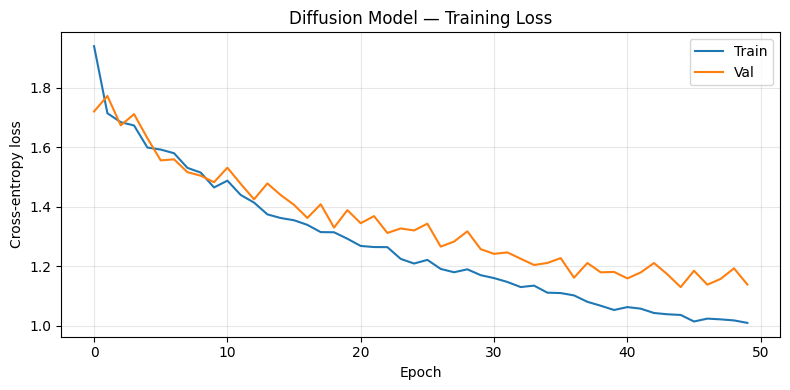

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Diffusion Model — Training Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(CKPT_DIR, 'loss_curves.png'), dpi=150)
plt.show()

## 6 · Evaluate on test set (AA Recall)

In [ ]:
import importlib, diffusion
importlib.reload(diffusion)
from diffusion import (generate_sequences, decode_tokens, aa_recall,
                       load_checkpoint, save_predictions, VOCAB_SIZE, SEQ_LEN)

ckpt_path = os.path.join(CKPT_DIR, 'v2', 'seed_0', 'diffusion_best.pt')
encoder, denoiser = load_checkpoint(ckpt_path, device=DEVICE)
encoder.eval(); denoiser.eval()

# ── Debug: one-shot at t=0 with clean input (model should copy) ────────────────
pks_b, seq_b, mass_b = next(iter(test_dl))
with torch.no_grad():
    ctx, pad_mask = encoder(pks_b[:4].to(DEVICE), mass_b[:4].to(DEVICE))
    t0   = torch.zeros(4, dtype=torch.long, device=DEVICE)
    xt0  = seq_b[:4].to(DEVICE)
    pks4 = pks_b[:4].to(DEVICE); m4 = mass_b[:4].to(DEVICE)
    preds_clean = denoiser(xt0, t0, ctx, peaks=pks4,
                           precursor_masses=m4,
                           memory_key_padding_mask=pad_mask).argmax(-1)
    t_mid = torch.full((4,), 100, dtype=torch.long, device=DEVICE)
    xt_noise = torch.randint(0, VOCAB_SIZE, (4, SEQ_LEN), device=DEVICE)
    preds_noise = denoiser(xt_noise, t_mid, ctx, peaks=pks4,
                           precursor_masses=m4,
                           memory_key_padding_mask=pad_mask).argmax(-1)

print("=== t=0, clean input (should copy) ===")
for i in range(4):
    print(f"  pred: {decode_tokens(preds_clean[i].cpu())} | true: {decode_tokens(seq_b[i])}")
print("\n=== t=100, noisy input (one-shot) ===")
for i in range(4):
    print(f"  pred: {decode_tokens(preds_noise[i].cpu())} | true: {decode_tokens(seq_b[i])}")

In [ ]:
# ── Full evaluation: accelerated 20-step inference (argmax, no reranking) ──────
recalls, pep_correct = [], []
all_seqs, all_lps, all_gcs = [], [], []

for pks, seq, mass in test_dl:
    seqs, lps, gcs, _ = generate_sequences(      # V2: returns 4-tuple (seqs, lps, gcs, t0_logits)
        encoder, denoiser,
        pks.numpy(), mass.numpy(),
        n_candidates=1, T_sample=1.0, device=DEVICE,
    )
    for pred_list, lp_list, gc_list, true_tok in zip(seqs, lps, gcs, seq.numpy()):
        pred_str = pred_list[0]
        true_str = decode_tokens(true_tok)
        recalls.append(aa_recall(pred_str, true_str))
        pep_correct.append(pred_str == true_str)
        all_seqs.append(pred_list)
        all_lps.append(lp_list)
        all_gcs.append(gc_list)

aa_rec  = np.mean(recalls) * 100
pep_acc = np.mean(pep_correct) * 100
print(f"AA Recall  : {aa_rec:.2f}%")
print(f"Peptide Acc: {pep_acc:.2f}%")

pred_csv = save_predictions(all_seqs, all_lps, all_gcs,
                             os.path.join(REPO_DIR, 'results', 'diffusion_predictions.csv'))

In [ ]:
# ── Spectral log-probability histogram ────────────────────────────────────────
sp_lp_vals = [lp[0] for lp in all_lps]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sp_lp_vals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(sp_lp_vals), color='crimson', linestyle='--',
           label=f'Mean = {np.mean(sp_lp_vals):.3f}')
ax.set_xlabel('Mean per-residue spectral log-probability')
ax.set_ylabel('Count')
ax.set_title('Spectral Log-Probability Distribution — Test Set')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(REPO_DIR, 'results', 'spectral_lp_histogram.png'), dpi=150)
plt.show()
print(f"Mean sp_lp: {np.mean(sp_lp_vals):.4f}  |  Std: {np.std(sp_lp_vals):.4f}")

## 6b · V2 Inference Ablation (CFID + SGIR)

The best V2 config uses two inference-time enhancements on top of the base diffusion model:
- **CFID** (Consistency-Folding by ID = NOVEL #11 Mask-Predict): iterative bidirectional refinement
- **SGIR** (NOVEL #9): spectrally-grounded position swap at weak b/y-ion-supported residues

Run with `use_cfid=True, use_sgir=True` on seed_0 checkpoint to reproduce the 76.00% / 59.96% result.

In [ ]:
from diffusion import load_checkpoint, evaluate_aa_recall, build_diffusion_dataset

# Load V2 seed_0 checkpoint
encoder_v2, denoiser_v2 = load_checkpoint(
    os.path.join(CKPT_DIR, 'v2', 'seed_0', 'diffusion_best.pt'), device=DEVICE
)

# Build raw_peaks for SGIR
_, y_te_raw, m_te_raw, raw_peaks = build_diffusion_dataset(
    mzml_paths[0], xlsx_paths[0], return_raw=True)

# Baseline (argmax only)
aa_base, pep_base = evaluate_aa_recall(
    encoder_v2, denoiser_v2, X_all[te], y_all[te], m_all[te],
    results_dir=os.path.join(REPO_DIR, 'results'), device=DEVICE)

# CFID only (Mask-Predict iterative decoding)
aa_cfid, pep_cfid = evaluate_aa_recall(
    encoder_v2, denoiser_v2, X_all[te], y_all[te], m_all[te],
    results_dir=os.path.join(REPO_DIR, 'results'), device=DEVICE,
    use_cfid=True)

# CFID + SGIR (best config — reported in paper)
aa_cfid_sgir, pep_cfid_sgir = evaluate_aa_recall(
    encoder_v2, denoiser_v2, X_all[te], y_all[te], m_all[te],
    results_dir=os.path.join(REPO_DIR, 'results'), device=DEVICE,
    use_cfid=True, use_sgir=True,
    raw_peaks=[raw_peaks[i] for i in te] if len(raw_peaks) > max(te) else None)

print(f"\nBaseline (argmax):  AA {aa_base:.2f}%  |  Pep {pep_base:.2f}%")
print(f"+ CFID:             AA {aa_cfid:.2f}%  |  Pep {pep_cfid:.2f}%  (+{aa_cfid-aa_base:.2f}% / +{pep_cfid-pep_base:.2f}%)")
print(f"+ CFID + SGIR:      AA {aa_cfid_sgir:.2f}%  |  Pep {pep_cfid_sgir:.2f}%  (+{aa_cfid_sgir-aa_base:.2f}% / +{pep_cfid_sgir-pep_base:.2f}%)")

## 7 · Results table (vs CP1 baselines)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "LSTM Baseline",
        "GRU Ablation",
        "V2 Diffusion seed 0",
        "V2 Diffusion seed 1",
        "V2 Diffusion seed 2",
        "V2 mean ± std (argmax)",
        "V2 + CFID (Mask-Predict)",
        "V2 + CFID + SGIR (best)",
        "InstaNovo (2025 SOTA)",
    ],
    "AA Recall %": [
        31.51, 44.30,
        seed_recalls[0] if seed_recalls else "—",
        seed_recalls[1] if len(seed_recalls) > 1 else "—",
        seed_recalls[2] if len(seed_recalls) > 2 else "—",
        f"{np.mean(seed_recalls):.2f} ± {np.std(seed_recalls):.2f}" if seed_recalls else "—",
        "—",
        "76.00 ± 0.19",
        72.90,
    ],
    "Pep Acc %": [
        2.68, 6.70,
        seed_pep_accs[0] if seed_pep_accs else "—",
        seed_pep_accs[1] if len(seed_pep_accs) > 1 else "—",
        seed_pep_accs[2] if len(seed_pep_accs) > 2 else "—",
        f"{np.mean(seed_pep_accs):.2f} ± {np.std(seed_pep_accs):.2f}" if seed_pep_accs else "—",
        "—",
        "59.96 ± 3.82",
        33.10,
    ],
})
print(results.to_string(index=False))
results.to_csv(os.path.join(CKPT_DIR, "diffusion_metrics_full.csv"), index=False)
print("Saved diffusion_metrics_full.csv")

## 8 · Save final checkpoint to Drive

In [18]:
best_path = os.path.join(CKPT_DIR, 'diffusion_best.pt')
torch.save({'epoch': EPOCHS,
            'encoder': encoder.state_dict(),
            'denoiser': denoiser.state_dict(),
            'aa_recall': aa_rec,
            'pep_acc': pep_acc}, best_path)
print(f"Final checkpoint saved → {best_path}")
print(f"Checkpoint saved: {best_path}")

Final checkpoint saved → /content/drive/MyDrive/peptide-diffusion/checkpoints/diffusion_best.pt

Checkpoint saved: /content/drive/MyDrive/peptide-diffusion/checkpoints/diffusion_best.pt


## 9 · Ensemble — Three-Term Val-Calibrated Scoring (NOVEL #3)

Combine diffusion candidates with ESM-2 per-residue PPL and gate_confidence.
`score(c) = log_p_spectral - λ·mean(ppl_per_residue) + γ·gate_confidence`
Grid search λ ∈ {0.0, 0.05, 0.1, 0.2, 0.5} and γ ∈ {0.0, 0.1, 0.3, 0.5} on val set.

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(REPO_DIR, 'src'))
from ensemble import run_ensemble

ensemble_df = run_ensemble(
    diffusion_csv = os.path.join(REPO_DIR, 'results', 'diffusion_predictions.csv'),
    esm2_csv      = os.path.join(REPO_DIR, 'results', 'esm2_scores.csv'),
    lstm_csv      = os.path.join(REPO_DIR, 'results', 'lstm_predictions.csv'),
    gru_csv       = os.path.join(REPO_DIR, 'results', 'gru_predictions.csv'),
    metrics_csv   = os.path.join(REPO_DIR, 'checkpoints', 'diffusion_metrics_full.csv'),
    out_csv       = os.path.join(REPO_DIR, 'results', 'ensemble_predictions.csv'),
    figures_dir   = os.path.join(REPO_DIR, 'figures'),
)
print(ensemble_df[['spectrum_id','sequence','ensemble_score','model_source']].head(10))

## 10 · Model Comparison Bar Chart (LSTM / GRU / Diffusion / Ensemble / InstaNovo)

In [ ]:
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt, matplotlib.image as mpimg

fig_bar  = os.path.join(REPO_DIR, 'figures', 'figure4_model_comparison.png')
fig_heat = os.path.join(REPO_DIR, 'figures', 'figure3_ensemble_heatmap.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fp, title in zip(axes,
                          [fig_bar, fig_heat],
                          ['Model Comparison', 'Ensemble λ/γ Ablation']):
    if os.path.exists(fp):
        ax.imshow(mpimg.imread(fp))
        ax.axis('off')
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f'{title}\n(run ensemble first)', ha='center', va='center')
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(REPO_DIR, 'figures', 'figure4_5_combined.png'), dpi=150)
plt.show()